In [94]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

pandas (pd): Used for data manipulation and analysis.

numpy (np): Provides support for numerical operations.

matplotlib.pyplot (plt): Used for visualizing data through graphs.

seaborn (sns): Built on top of Matplotlib, used for statistical data visualization.

sklearn.model_selection (train_test_split): Splits dataset into training and testing sets.

sklearn.preprocessing (StandardScaler, LabelEncoder): Used for feature scaling and encoding categorical variables.

In [95]:
df = pd.read_csv("C:/Users/amama/Downloads/Crop_recommendation.csv")

Loads the dataset into a Pandas DataFrame.

The dataset is read from a CSV  file and stored in a DataFrame (df).

Think of df like an Excel sheet: It contains rows (data points) and columns (features like temperature, humidity, etc.).

In [96]:
# Remove duplicates
df = df.drop_duplicates()


Removes duplicate rows to avoid bias in the model.
Ensures that each row represents unique data.

Why? Duplicate data can mislead the machine learning model.

In [97]:
# Fix column names (strip extra spaces)
df.columns = df.columns.str.strip()

Strips any leading or trailing spaces from column names.
Example:
Before: " temperature "
After: "temperature"

In [98]:
# Display dataset summary
print("\nDataset Summary:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())


Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

First 5 Rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.6

df.info():
Displays column names, data types (integer, float, string), and memory usage.
Helps to understand what type of data is stored (e.g., numbers, text).

df.head():
Shows the first 5 rows of the dataset.
Useful for quickly checking what the data looks like.

In [99]:
# Handle missing values (if any)
print("\nMissing Values Before Handling:")
print(df.isnull().sum())  # Check for missing values

# Check for missing values and handle them if necessary
df = df.dropna()


Missing Values Before Handling:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


df.isnull().sum():
Checks if there are any missing values (NaN).
Displays the count of missing values for each column.

df = df.dropna()
Drops (removes) rows with missing values.
Alternative: Instead of removing rows, we could fill missing values using df.fillna().

In [100]:
# Display the number of rows and columns
print("\nDataset Shape (Rows, Columns):", df.shape)


Dataset Shape (Rows, Columns): (2200, 8)


Displays the number of rows and columns in the cleaned dataset.

In [101]:
# Encode target variable (label encoding for categorical target)
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

Converts the crop names (categorical) into numerical values for machine learning models.
Example:

Before:  label = ["Rice", "Wheat", "Maize"]
After:   label = [0, 1, 2]  

In [102]:
numerical_cols = [col for col in df.columns if col not in ['label']]


Creates a list of numerical columns by excluding the target variable (label).
Why? We need to treat numerical and categorical data differently.

In [103]:
# Splitting features and target
X = df.drop(columns=['label'])
y = df['label']

X: Contains features (independent variables like temperature, humidity).
y: Contains target variable (label, which represents the crop).

In [104]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Splitting the Dataset

X: Contains independent features (excluding label).
y: Contains the target variable (label).
Splits data into training (80%) and testing (20%) sets.
Uses stratify=y to ensure balanced class distribution.

Why? Training data is used to teach the model, and test data checks if the model performs well.

In [105]:
# Standardizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Feature Scaling
Standardizes numerical features to ensure a consistent scale for machine learning models.

Scales numerical data to have zero mean and unit variance.


In [106]:
# Convert standardized arrays back to DataFrame for visualization
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Display the first five rows of the processed training data
print("Processed Training Data:")
print(X_train_df.head())

# Display the first five rows of the encoded target variable
print("\nEncoded Target Labels:")
print(y_train[:5])


Processed Training Data:
          N         P         K  temperature  humidity        ph  rainfall
0 -1.371628 -1.072910 -0.673510     0.819481  0.924395  0.937545  0.199440
1 -1.127411  2.084513  3.015261     0.783251  0.426613 -1.153846 -0.643677
2 -1.073140  0.536162 -0.476250    -0.879968 -2.186291 -1.107452  0.694001
3 -0.340487 -0.465713 -0.594606     0.138043 -0.459237 -0.229482 -1.231744
4 -0.883193 -1.255069 -0.791866    -2.563232  0.915842 -0.341959  0.289941

Encoded Target Labels:
1607    16
1212     7
362      9
566     13
1671    16
Name: label, dtype: int32


In [107]:
num_rows = df.shape[0]
print(f"Number of rows in the dataset: {num_rows}")



Number of rows in the dataset: 2200


In [108]:
# Identify categorical and numerical columns
categorical_cols = ['label']  # If there are any categorical columns
numerical_cols = [col for col in df.columns if col not in categorical_cols]


<Figure size 1200x800 with 0 Axes>

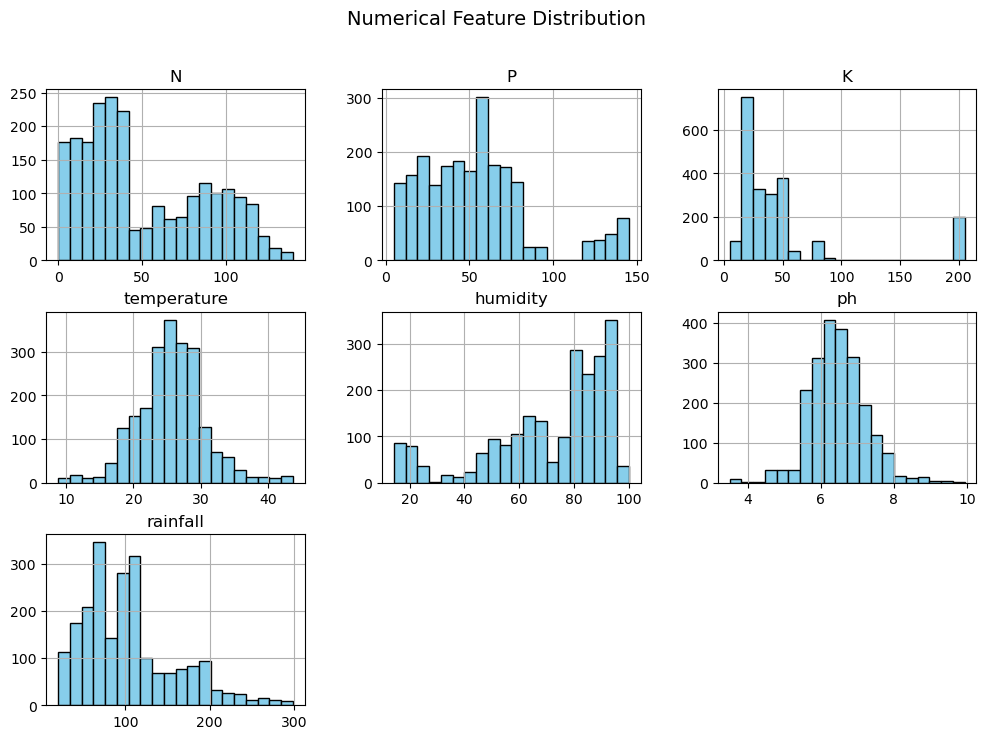

In [109]:
#  **Distribution of numerical features**
plt.figure(figsize=(12, 8))
df[numerical_cols].hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Numerical Feature Distribution", fontsize=14)
plt.show()

Histogram - Numerical Feature Distribution

Plots histograms to show the distribution of numerical features

<Figure size 1200x600 with 0 Axes>

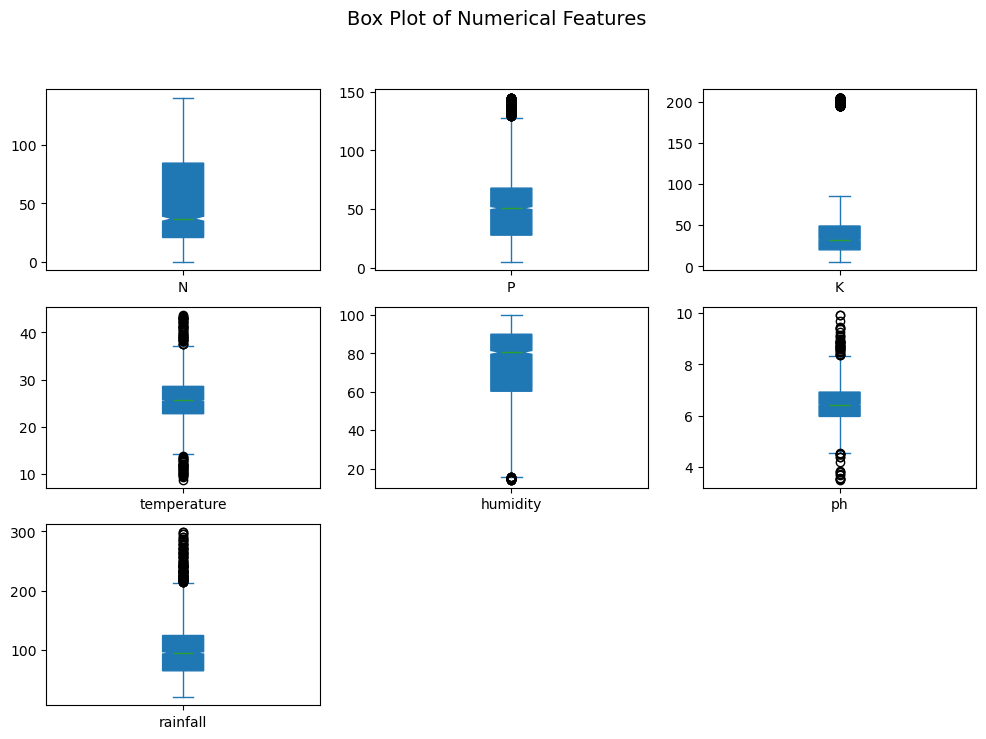

In [110]:
# **Box plot to check for outliers**
plt.figure(figsize=(12, 6))
df[numerical_cols].plot(kind='box', subplots=True, layout=(3, 3), figsize=(12, 8), notch=True, patch_artist=True)
plt.suptitle("Box Plot of Numerical Features", fontsize=14)
plt.show()

Box Plots - Identifying Outliers
Uses box plots to identify outliers in numerical features.

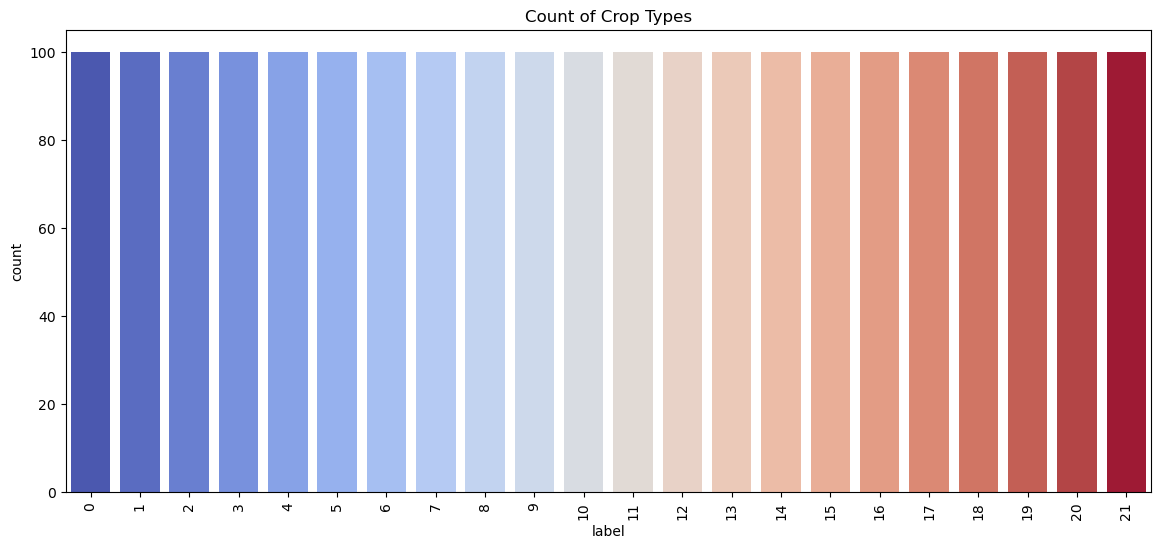

In [111]:
plt.figure(figsize=(14, 6))
sns.countplot(x='label', data=df, hue='label', palette='coolwarm', legend=False)
plt.title("Count of Crop Types")
plt.xticks(rotation=90)
plt.show()


Count Plot - Distribution of Crop Types
Shows the distribution of crop types in the dataset.

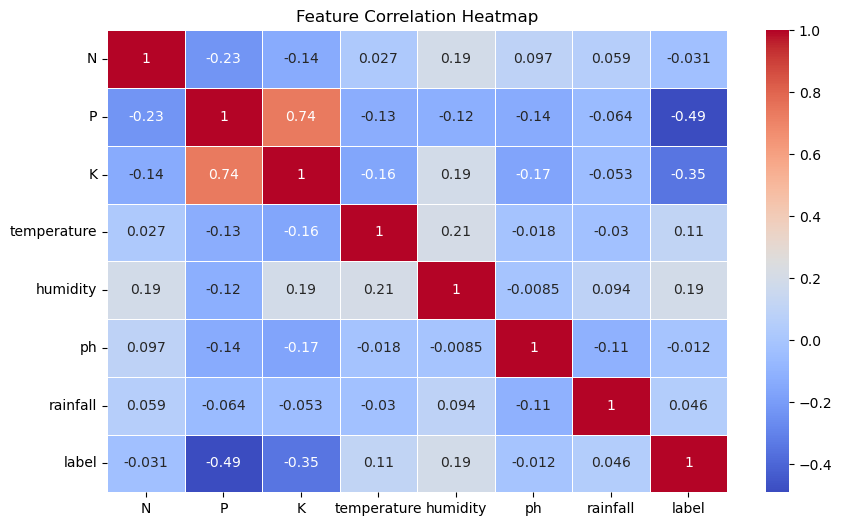

In [112]:
# **Correlation Heatmap**
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


Correlation Heatmap
Displays the correlation between different features, helping identify relationships between them.

this code:

Loads and cleans the dataset.
Checks for missing values and removes them.
Encodes categorical values (Crop Type).
Splits data into training and test sets.
Standardizes numerical features.
Visualizes the dataset using graphs.

In [113]:
df.to_csv("C:/Users/amama/Downloads/Crop_recommendation_cleaned.csv", index=False)
print("Cleaned dataset saved to Crop_recommendation_cleaned.csv")

Cleaned dataset saved to Crop_recommendation_cleaned.csv


In [114]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

RandomOverSampler: Used to balance the dataset by duplicating samples from the minority class.

SMOTEENN: Combines SMOTE (creates synthetic samples) and ENN (removes noisy samples) to improve dataset quality.

RobustScaler: Scales feature values while reducing the effect of outliers.

GradientBoostingClassifier: A machine-learning model that builds many small decision trees to improve prediction accuracy.

train_test_split: Splits the dataset into training and testing sets.

learning_curve: Plots how model performance changes as the training size increases.

classification_report: Provides precision, recall, F1-score, and support for each class.

confusion_matrix: Shows how many predictions were correct or incorrect for each class.

accuracy_score: Returns the model’s overall accuracy.

In [115]:
label_classes = le.classes_
print("Encoded class mapping (index -> crop name):")
for idx, name in enumerate(label_classes):
    print(f"{idx} -> {name}")

Encoded class mapping (index -> crop name):
0 -> apple
1 -> banana
2 -> blackgram
3 -> chickpea
4 -> coconut
5 -> coffee
6 -> cotton
7 -> grapes
8 -> jute
9 -> kidneybeans
10 -> lentil
11 -> maize
12 -> mango
13 -> mothbeans
14 -> mungbean
15 -> muskmelon
16 -> orange
17 -> papaya
18 -> pigeonpeas
19 -> pomegranate
20 -> rice
21 -> watermelon


label_classes = le.classes_
Gets the list of original crop names that were encoded by LabelEncoder.

print("Encoded class mapping (index -> crop name):")
Prints a heading to show what the mapping below represents.

for idx, name in enumerate(label_classes):
Loops through each class label and gives it an index number.

print(f"{idx} -> {name}")
Prints the encoded index (idx) and its corresponding crop name (name).

In [116]:
import warnings
from imblearn.over_sampling import RandomOverSampler
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import learning_curve
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

import warnings
Imports Python’s built-in module to control and manage warning messages.

from imblearn.over_sampling import RandomOverSampler
Imports RandomOverSampler to balance classes by copying minority samples.

from imblearn.combine import SMOTEENN
Imports SMOTEENN, which both creates synthetic samples and removes noisy samples.

from sklearn.preprocessing import RobustScaler
Imports RobustScaler to scale features while reducing the impact of outliers.

from sklearn.ensemble import GradientBoostingClassifier
Imports the Gradient Boosting model used for classification tasks.

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
Imports functions to evaluate the model: detailed report, confusion matrix, and accuracy.

from sklearn.model_selection import learning_curve
Imports learning_curve to study how model performance changes with more training data.

from sklearn.exceptions import UndefinedMetricWarning
Imports a specific warning type that appears when some metrics cannot be computed.

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
Tells Python to hide any UndefinedMetricWarning messages during training/evaluation.

In [117]:
oversampler = RandomOverSampler(random_state=42)
smote_enn = SMOTEENN(random_state=42)

oversampler = RandomOverSampler(random_state=42)
Creates a RandomOverSampler object to balance the classes by duplicating minority samples, with 42 used to keep results reproducible.

smote_enn = SMOTEENN(random_state=42)
Creates a SMOTEENN object that first generates synthetic samples (SMOTE) and then removes noisy samples (ENN), also using 42 for reproducible results.

In [118]:
X_resampled, y_resampled = oversampler.fit_resample(X, y)
X_resampled, y_resampled = smote_enn.fit_resample(X_resampled, y_resampled)

X_resampled, y_resampled = oversampler.fit_resample(X, y)
Applies RandomOverSampler to duplicate minority-class samples and balance the dataset.

X_resampled, y_resampled = smote_enn.fit_resample(X_resampled, y_resampled)
Applies SMOTEENN on the oversampled data to create synthetic samples (SMOTE) and remove noisy or incorrect samples (ENN).

In [119]:
print("\nOriginal dataset shape:", X.shape, y.shape)
print("After oversampling + SMOTEENN:", X_resampled.shape, y_resampled.shape)


Original dataset shape: (2200, 7) (2200,)
After oversampling + SMOTEENN: (2094, 7) (2094,)


print("\nOriginal dataset shape:", X.shape, y.shape)
Prints the shape (rows, columns) of the original features X and labels y before resampling.

print("After oversampling + SMOTEENN:", X_resampled.shape, y_resampled.shape)
Prints the shape of the new resampled features and labels after applying RandomOverSampler and SMOTEENN.

In [120]:
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

train_test_split(
Starts the function to split the resampled data into training and testing sets.

X_resampled,
Uses the resampled feature dataset as input for splitting.

y_resampled,
Uses the resampled target labels for the split.

test_size=0.2,
Sets 20% of the data for testing and 80% for training.

random_state=42,
Ensures the split is reproducible every time the code runs.

stratify=y_resampled
Ensures the class proportions remain equal in both training and testing splits.

In [121]:
gb_scaler = RobustScaler()
X_train_scaled = gb_scaler.fit_transform(X_train_gb)
X_test_scaled = gb_scaler.transform(X_test_gb)

gb_scaler = RobustScaler()
Creates a RobustScaler object that scales data while reducing the effect of outliers.

X_train_scaled = gb_scaler.fit_transform(X_train_gb)
Fits the scaler to the training data and scales it at the same time.

X_test_scaled = gb_scaler.transform(X_test_gb)
Applies the already-fitted scaler to the test data to keep scaling consistent.

In [122]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train_scaled, y_train_gb)

GradientBoostingClassifier(random_state=42)

gb_clf = GradientBoostingClassifier(
Creates a Gradient Boosting classifier model.

n_estimators=100,
Builds 100 small decision trees for boosting.

learning_rate=0.1,
Controls how much each tree contributes to the final model.

max_depth=3,
Limits each decision tree to a depth of 3 to prevent overfitting.

random_state=42
Ensures consistent, reproducible model results.

gb_clf.fit(X_train_scaled, y_train_gb)
Trains the Gradient Boosting model using the scaled training data.

In [123]:
y_pred_gb = gb_clf.predict(X_test_scaled)

y_pred_gb =
Stores the model’s predictions in a variable.

gb_clf.predict
Uses the trained Gradient Boosting model to make predictions.

X_test_scaled
Provides the scaled test data for prediction.

In [124]:
print("\n=========== CONFUSION MATRIX (Gradient Boosting) ===========")
print(confusion_matrix(y_test_gb, y_pred_gb))

print("\n=========== CLASSIFICATION REPORT (Gradient Boosting) ===========")
print(classification_report(y_test_gb, y_pred_gb))

print("Accuracy score (Gradient Boosting):", accuracy_score(y_test_gb, y_pred_gb))


=========== CONFUSION MATRIX (Gradient Boosting) ===========
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 

print(confusion_matrix(y_test_gb, y_pred_gb))
Displays the confusion matrix comparing actual vs. predicted labels.

print(classification_report(y_test_gb, y_pred_gb))
Shows precision, recall, F1-score, and support for each class.

print("Accuracy score (Gradient Boosting):", accuracy_score(y_test_gb, y_pred_gb))
Prints the overall accuracy of the model’s predictions.

In [125]:
from sklearn.metrics import log_loss

# Use the *same* scaled training set and training labels as above:
# X_train_scaled, y_train_gb, X_test_scaled, y_test_gb

# 1) Create explicit train/validation split from training data
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_scaled,
    y_train_gb,
    test_size=0.2,
    random_state=42,
    stratify=y_train_gb
)

# 2) Define a more regularized GB model with early stopping
gb_clf_fixed = GradientBoostingClassifier(
    n_estimators=1000,          # upper bound; ES will stop earlier
    learning_rate=0.05,         # smaller step -> smoother learning
    max_depth=3,
    subsample=0.8,              # stochastic GBM
    min_samples_leaf=5,         # avoid tiny leaves
    validation_fraction=0.2,    # internal validation split from train_sub
    n_iter_no_change=10,        # stop if no improvement
    tol=1e-4,
    random_state=42
)

gb_clf_fixed.fit(X_train_sub, y_train_sub)

# 3) Predictions + probabilities on train/val/test
y_train_fixed = gb_clf_fixed.predict(X_train_sub)
y_val_fixed   = gb_clf_fixed.predict(X_val_sub)
y_test_fixed  = gb_clf_fixed.predict(X_test_scaled)

y_train_fixed_proba = gb_clf_fixed.predict_proba(X_train_sub)
y_val_fixed_proba   = gb_clf_fixed.predict_proba(X_val_sub)
y_test_fixed_proba  = gb_clf_fixed.predict_proba(X_test_scaled)

# 4) Accuracies
train_acc = accuracy_score(y_train_sub, y_train_fixed)
val_acc   = accuracy_score(y_val_sub, y_val_fixed)
test_acc  = accuracy_score(y_test_gb, y_test_fixed)

# 5) Losses (log loss)
train_loss = log_loss(y_train_sub, y_train_fixed_proba)
val_loss   = log_loss(y_val_sub, y_val_fixed_proba)
test_loss  = log_loss(y_test_gb, y_test_fixed_proba)

print("\nAccuracy and loss of the best model :")
print(f"Train accuracy: {train_acc*100:.3f} % || Validation accuracy: {val_acc*100:.3f} % || Test accuracy: {test_acc*100:.3f} %")
print(f"Train loss: {train_loss:.3f} || Validation loss: {val_loss:.3f} || Test loss: {test_loss:.3f}")


Accuracy and loss of the best model :
Train accuracy: 99.701 % || Validation accuracy: 99.403 % || Test accuracy: 99.523 %
Train loss: 0.012 || Validation loss: 0.034 || Test loss: 0.017


In [127]:
train_sizes, train_scores, test_scores = learning_curve(
    gb_clf,
    X_resampled,
    y_resampled,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)



This uses learning_curve to evaluate how the Gradient Boosting model (gb_clf) performs as we increase the amount of training data.

X_resampled, y_resampled → the full balanced dataset.

cv=5 → uses 5-fold cross-validation.

scoring='accuracy' → measures accuracy for each training size.

train_sizes → different fractions of the training data (from 10% to 100%).

In [128]:
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)



These lines summarize the results from cross-validation.

For each training size:

train_scores_mean / test_scores_mean → average accuracy over the 5 folds.

train_scores_std / test_scores_std → how much the scores vary (spread) over the folds.

This is used to plot smooth curves with shaded regions

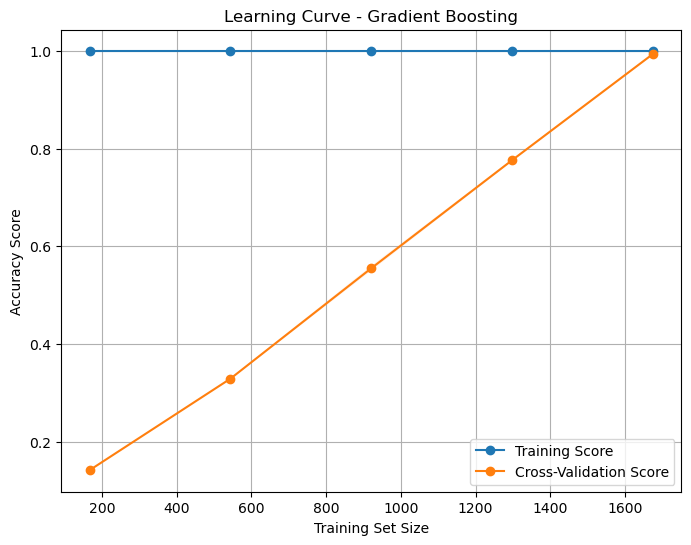

In [129]:
plt.figure(figsize=(8, 6))
plt.title('Learning Curve - Gradient Boosting')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.grid()
plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.1)
plt.fill_between(train_sizes,
                 test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std,
                 alpha=0.1)
plt.plot(train_sizes, train_scores_mean, 'o-', label='Training Score')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Cross-Validation Score')
plt.legend(loc='best')
plt.show()


creates a Learning Curve graph that shows how your model’s accuracy changes as the training data increases.

plt.figure(figsize=(8, 6))
Creates a new graph with size 8×6 inches.

plt.title('Learning Curve - Gradient Boosting')
Sets the title of the graph.

plt.xlabel('Training Set Size') and plt.ylabel('Accuracy Score')
Labels the X-axis (amount of training data) and Y-axis (accuracy).

plt.grid()
Adds background grid lines for easier reading of the graph.

plt.fill_between(...) (two times)
Draws shaded regions around both the training and validation scores.
These show the variation (standard deviation)—wide shading means unstable performance.

plt.plot(train_sizes, train_scores_mean, 'o-', label='Training Score')
Plots the training accuracy as the dataset grows.

plt.plot(train_sizes, test_scores_mean, 'o-', label='Cross-Validation Score')
Plots the validation accuracy (performance on unseen data).

plt.legend(loc='best')
Adds a legend identifying the two lines.

plt.show()
Displays the final learning curve graph.

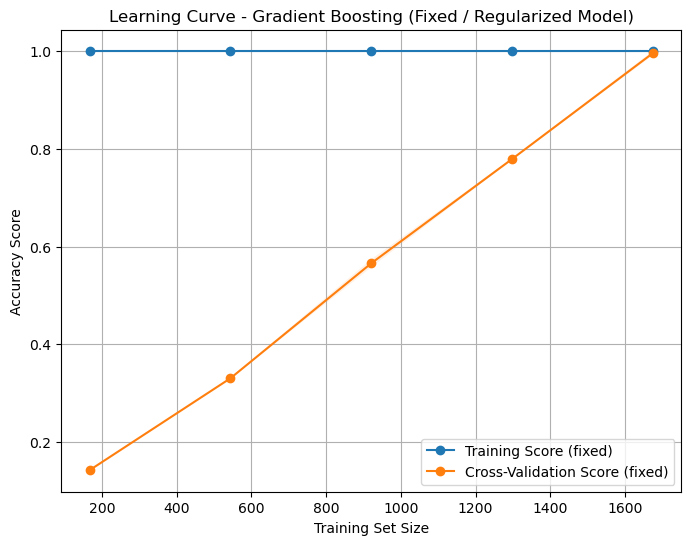


[Fixed GB model] Accuracy and loss of the best model :
Train accuracy: 99.701 % || Validation accuracy: 99.403 % || Test accuracy: 99.523 %
Train loss: 0.012 || Validation loss: 0.034 || Test loss: 0.017


In [131]:
from sklearn.model_selection import StratifiedKFold

# Use a version of the fixed model *without* early stopping
gb_clf_lc = GradientBoostingClassifier(
    n_estimators=gb_clf_fixed.n_estimators,
    learning_rate=gb_clf_fixed.learning_rate,
    max_depth=gb_clf_fixed.max_depth,
    subsample=gb_clf_fixed.subsample,
    min_samples_leaf=gb_clf_fixed.min_samples_leaf,
    random_state=42
    # NOTE: no validation_fraction, no n_iter_no_change here
)

cv_fixed = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes_fixed, train_scores_fixed, test_scores_fixed = learning_curve(
    gb_clf_lc,
    X_resampled,
    y_resampled,
    cv=cv_fixed,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean_fixed = np.mean(train_scores_fixed, axis=1)
train_scores_std_fixed  = np.std(train_scores_fixed, axis=1)
test_scores_mean_fixed  = np.mean(test_scores_fixed, axis=1)
test_scores_std_fixed   = np.std(test_scores_fixed, axis=1)

plt.figure(figsize=(8, 6))
plt.title('Learning Curve - Gradient Boosting (Fixed / Regularized Model)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.grid()
plt.fill_between(train_sizes_fixed,
                 train_scores_mean_fixed - train_scores_std_fixed,
                 train_scores_mean_fixed + train_scores_std_fixed,
                 alpha=0.1)
plt.fill_between(train_sizes_fixed,
                 test_scores_mean_fixed - test_scores_std_fixed,
                 test_scores_mean_fixed + test_scores_std_fixed,
                 alpha=0.1)
plt.plot(train_sizes_fixed, train_scores_mean_fixed, 'o-', label='Training Score (fixed)')
plt.plot(train_sizes_fixed, test_scores_mean_fixed, 'o-', label='Cross-Validation Score (fixed)')
plt.legend(loc='best')
plt.show()

# Re-print the nice summary right under this plot
print("\n[Fixed GB model] Accuracy and loss of the best model :")
print(f"Train accuracy: {train_acc*100:.3f} % || Validation accuracy: {val_acc*100:.3f} % || Test accuracy: {test_acc*100:.3f} %")
print(f"Train loss: {train_loss:.3f} || Validation loss: {val_loss:.3f} || Test loss: {test_loss:.3f}")


In [137]:
# ============================================================
# NEW: Automatically choose best model (original vs fixed)
#       and save it as crop_pred_new_model.pkl
# ============================================================

# Original model test accuracy
orig_test_acc = accuracy_score(y_test_gb, y_pred_gb)

# Fixed model test accuracy (already computed earlier as test_acc)
fixed_test_acc = test_acc

if fixed_test_acc >= orig_test_acc:
    best_model = gb_clf_fixed
    best_model_name = "fixed (regularized) Gradient Boosting"
else:
    best_model = gb_clf
    best_model_name = "original Gradient Boosting"

import pickle

with open("crop_pred_new_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("\n================ MODEL SELECTION ================")
print(f"Original GB test accuracy : {orig_test_acc:.4f}")
print(f"Fixed GB test accuracy    : {fixed_test_acc:.4f}")
print(f"Best model selected    : {best_model_name}")
print("Saved as: crop_pred_new_model.pkl")



================ MODEL SELECTION ================
Original GB test accuracy : 1.0000
Fixed GB test accuracy    : 0.9952
Best model selected    : original Gradient Boosting
Saved as: crop_pred_new_model.pkl


In [138]:
print("\nEncoded class mapping (index -> crop name):")
for idx, name in enumerate(le.classes_):
    print(f"{idx} -> {name}")


Encoded class mapping (index -> crop name):
0 -> apple
1 -> banana
2 -> blackgram
3 -> chickpea
4 -> coconut
5 -> coffee
6 -> cotton
7 -> grapes
8 -> jute
9 -> kidneybeans
10 -> lentil
11 -> maize
12 -> mango
13 -> mothbeans
14 -> mungbean
15 -> muskmelon
16 -> orange
17 -> papaya
18 -> pigeonpeas
19 -> pomegranate
20 -> rice
21 -> watermelon


le.classes_ contains all original crop names learned by LabelEncoder.

enumerate(le.classes_) gives each crop name an index (0, 1, 2, …).

Inside the loop, print(f"{idx} -> {name}") shows:
encoded number → actual crop name
e.g. 0 -> rice, 1 -> maize, etc.

In [141]:


# === save ONLY the best model here ===
import pickle

with open("crop_pred_new_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("\nSaved best model:", best_model_name, "as crop_pred_new_model.pkl")


Saved best model: original Gradient Boosting as crop_pred_new_model.pkl


importances = gb_clf.feature_importances_
Gets the importance score of each feature learned by the Gradient Boosting model.

feature_names = X.columns
Stores the names of all input features (like N, P, K, temperature, etc.).

indices = np.argsort(importances)[::-1]
Sorts the feature importance scores from highest to lowest, so you can see which features matter most.

plt.figure(figsize=(10, 6))
Creates a new plot window with a size of 10×6 inches.

plt.title("Feature Importances - Gradient Boosting")
Sets the title for the graph.

plt.bar(range(len(importances)), importances[indices], align="center")
Draws a bar chart showing how important each feature is (sorted from most to least important).

plt.xticks(...)
Replaces the x-axis numbers with the actual feature names and rotates them for better readability.

plt.tight_layout()
Automatically adjusts spacing so labels don’t overlap.

plt.show()
Displays the final feature importance bar chart.

import pickle
Imports the pickle module, which is used to save and load Python objects to/from files.

with open("crop_pred_new_model.pkl", "wb") as f:
Opens a new file named crop_gb_model.pkl in write-binary mode to store the trained model.


print("\nSaved: crop_pred_model_new_model.pkl")

In [142]:
def predict_crop(sample_dict):
    """
    sample_dict example:
    {
        'N': 90,
        'P': 42,
        'K': 43,
        'temperature': 20.5,
        'humidity': 82.0,
        'ph': 6.5,
        'rainfall': 202.9
    }
    """
    sample_df = pd.DataFrame([sample_dict], columns=X.columns)
    sample_scaled = gb_scaler.transform(sample_df)
    pred_encoded = gb_clf.predict(sample_scaled)[0]
    pred_label = le.inverse_transform([pred_encoded])[0]
    return pred_label

This function takes one input sample (sample_dict) with all feature values (N, P, K, temperature, humidity, ph, rainfall).

It converts that dictionary into a single-row DataFrame (sample_df) using the same column order as your training data (X.columns).

Then it scales this input using the already-fitted gb_scaler so it matches the training scale.

The scaled data is passed to gb_clf.predict(...), which returns the encoded class (a number representing a crop).

le.inverse_transform(...) converts that encoded number back to the original crop name (like "rice", "maize", etc.).

Finally, return pred_label returns the predicted crop name

In [143]:
example_input = {
    'N': 90,
    'P': 42,
    'K': 43,
    'temperature': 20.5,
    'humidity': 82.0,
    'ph': 6.5,
    'rainfall': 202.9
}
print("\nExample prediction for:", example_input)
print("Predicted crop:", predict_crop(example_input))


Example prediction for: {'N': 90, 'P': 42, 'K': 43, 'temperature': 20.5, 'humidity': 82.0, 'ph': 6.5, 'rainfall': 202.9}
Predicted crop: rice
